In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import numpy as np

In [ ]:
(xtrain,ytrain),(xtest,ytest)=datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
xtrain.shape

(50000, 32, 32, 3)

In [ ]:
ytrain.shape

(50000, 1)

In [ ]:
ytrain.shape

(50000, 1)

In [ ]:
#create the ANN
ann=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000,activation="relu"),
    layers.Dense(1000,activation="relu"),
    layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
ann.compile(optimizer="SGD",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
ann.fit(xtrain,ytrain,epochs=5,validation_data=(xtest,ytest))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1000 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1000 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1000 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1000 - loss: nan - val_accuracy: 0.1000 - val_loss: nan
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1000 - loss: nan - val_accuracy: 0.1000 - val_loss: nan


In [ ]:
xtrain.flatten().shape

(153600000,)

In [ ]:
ytrain.shape

(50000, 1)

In [ ]:
cnn=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
cnn.fit(xtrain,ytrain,epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3719 - loss: 1.8474
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5316 - loss: 1.3156
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5966 - loss: 1.1581
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6313 - loss: 1.0579
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6580 - loss: 0.9848


In [ ]:
ypred=cnn.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
ypred

array([[2.01566541e-03, 6.08447357e-04, 5.38205868e-03, ...,
        6.38973783e-04, 1.08808875e-02, 4.10045846e-04],
       [1.60035521e-01, 1.22242600e-01, 1.71012889e-05, ...,
        2.30780688e-06, 7.12172747e-01, 5.51083311e-03],
       [2.59253114e-01, 3.48671198e-01, 7.65623990e-03, ...,
        5.40912105e-03, 2.00586110e-01, 1.65741891e-01],
       ...,
       [5.98943507e-06, 6.47353886e-07, 2.79676542e-02, ...,
        7.65824132e-03, 6.16956140e-06, 7.27829174e-05],
       [1.22789349e-02, 2.10613245e-03, 7.87610468e-03, ...,
        2.14255787e-03, 1.69424177e-03, 1.75519148e-04],
       [2.15989377e-04, 1.48794206e-05, 3.54763307e-02, ...,
        8.11740339e-01, 7.63541757e-05, 3.85622006e-05]], dtype=float32)

In [ ]:
from sklearn.metrics import classification_report

y_pred_classes = np.argmax(ypred, axis=1)

print(classification_report(ytest, y_pred_classes))

              precision    recall  f1-score   support

           0       0.69      0.68      0.68      1000
           1       0.69      0.84      0.76      1000
           2       0.48      0.51      0.50      1000
           3       0.47      0.34      0.40      1000
           4       0.56      0.62      0.59      1000
           5       0.49      0.62      0.55      1000
           6       0.64      0.78      0.70      1000
           7       0.80      0.62      0.70      1000
           8       0.73      0.77      0.75      1000
           9       0.88      0.50      0.64      1000

    accuracy                           0.63     10000
   macro avg       0.64      0.63      0.63     10000
weighted avg       0.64      0.63      0.63     10000



In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

**Visualizing CNN Predictions**

Let's visualize some of the images from the test set, along with their true labels and the model's predicted labels. This will help us understand where the model is performing well and where it's making mistakes.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_image_predictions(images, true_labels, predicted_labels, class_names, predictions, num_images=5):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(num_images, 1, i + 1)
        plt.imshow(images[i])
        true_label = class_names[true_labels[i][0]]
        predicted_label = class_names[predicted_labels[i]]

        # Get confidence for the predicted class
        confidence = predictions[i][predicted_labels[i]] * 100

        color = "green" if true_label == predicted_label else "red"
        plt.title(f"True: {true_label}, Predicted: {predicted_label} ({confidence:.2f}%) ", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Correctly Classified Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step


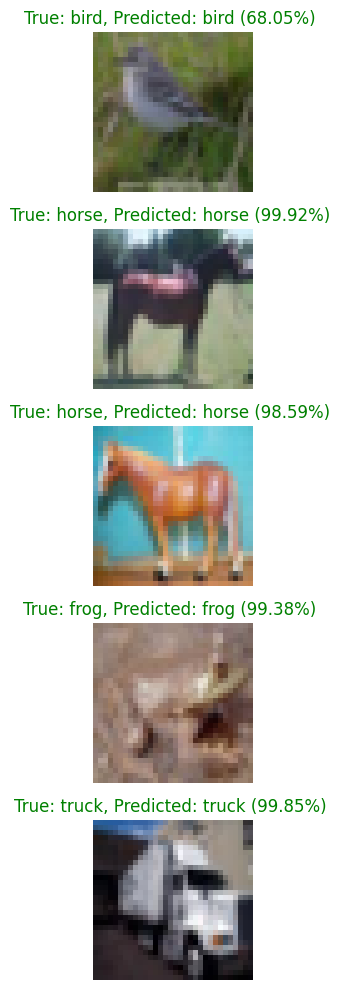

In [ ]:
correct_indices = np.where(y_pred_classes_combined == ytest.flatten())[0]

# Select a few random correctly classified images
np.random.seed(42) # for reproducibility
random_correct_indices = np.random.choice(correct_indices, 5, replace=False)

# Get predictions for these specific images
predictions_correct = cnn_combined.predict(xtest[random_correct_indices])
predicted_classes_correct = np.argmax(predictions_correct, axis=1)

plot_image_predictions(xtest[random_correct_indices], ytest[random_correct_indices], predicted_classes_correct, class_names, predictions_correct, num_images=5)

#### Incorrectly Classified Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


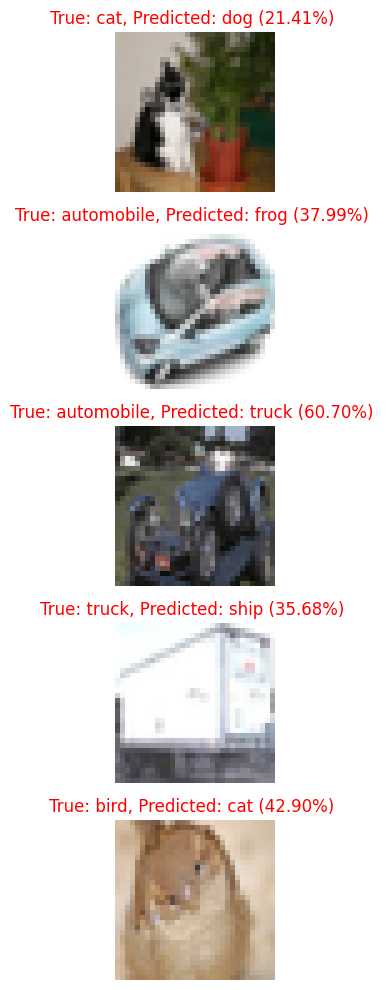

In [ ]:
incorrect_indices = np.where(y_pred_classes_combined != ytest.flatten())[0]

# Select a few random incorrectly classified images
np.random.seed(42) # for reproducibility
random_incorrect_indices = np.random.choice(incorrect_indices, 5, replace=False)

# Get predictions for these specific images
predictions_incorrect = cnn_combined.predict(xtest[random_incorrect_indices])
predicted_classes_incorrect = np.argmax(predictions_incorrect, axis=1)

plot_image_predictions(xtest[random_incorrect_indices], ytest[random_incorrect_indices], predicted_classes_incorrect, class_names, predictions_incorrect, num_images=5)

### Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect classifications for each class. It shows how many times an image of class A was predicted as class B.

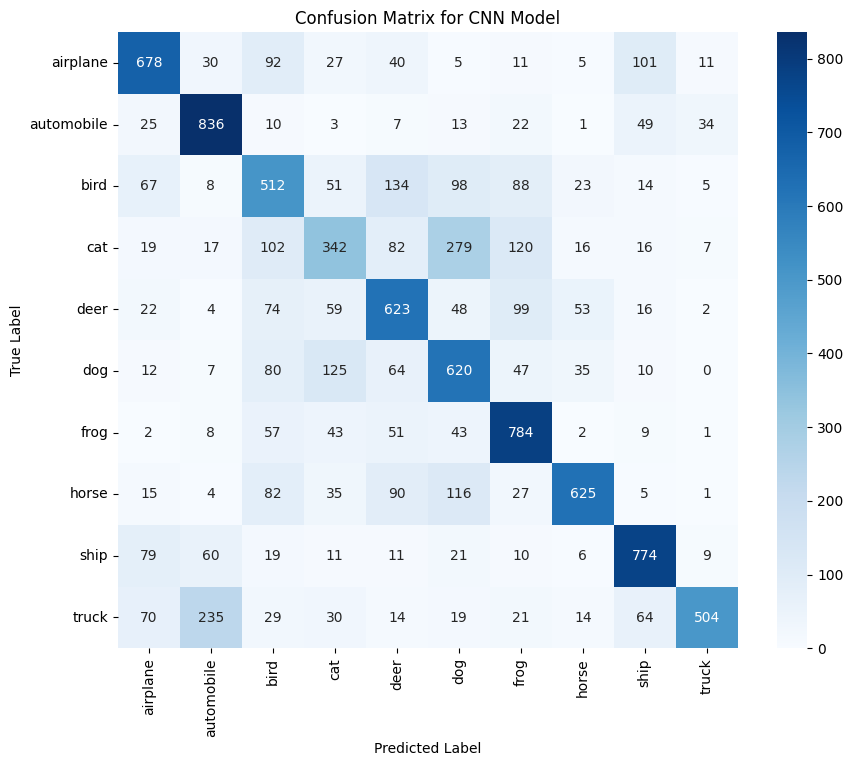

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(ytest, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Model')
plt.show()

**Next Steps for Model Improvement**

The confusion matrix and sample misclassifications highlight areas where the model struggles. For instance, cats and dogs are often confused, as are trucks and automobiles.

To improve the CNN model further, you could consider:

*   **Data Augmentation**: Applying transformations like rotations, flips, and zooms to the training images to make the model more robust.
*   **More Complex Architecture**: Adding more convolutional layers, increasing the number of filters, or using different types of layers (e.g., Batch Normalization, Dropout).
*   **Transfer Learning**: Using a pre-trained model on a large dataset (like ImageNet) and fine-tuning it for CIFAR-10.
*   **Hyperparameter Tuning**: Experimenting with different optimizers, learning rates, batch sizes, and number of epochs.
*   **Addressing Class Imbalance**: Although CIFAR-10 is balanced, for other datasets, this could be a factor.

Do you want to explore any of these improvement strategies, or would you like to compare the CNN with the ANN (keeping in mind the ANN's initial issues)? Let me know!

**Improving CNN Model: Data Augmentation**

Data augmentation is a technique to artificially increase the size of your training dataset by creating modified versions of images from the dataset. It helps in making the model more robust to variations in input and can reduce overfitting.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a data generator with various augmentation techniques
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Fit the data generator to the training data
datagen.fit(xtrain)

print("Data augmentation configured and fitted to training data.")

Data augmentation configured and fitted to training data.


**Retraining CNN with Data Augmentation**

Now, let's retrain the CNN model using the augmented data. We'll use the `flow` method of the `ImageDataGenerator` to feed batches of augmented images to the model during training.

In [ ]:
# Re-create the CNN model to ensure a fresh start for retraining
cnn_augmented = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
cnn_augmented.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Train the model using augmented data
history_augmented = cnn_augmented.fit(datagen.flow(xtrain, ytrain, batch_size=32),
                                      epochs=10, # Increased epochs for better training with augmented data
                                      validation_data=(xtest, ytest))

print("CNN model retrained with data augmentation.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.3563 - loss: 1.9570 - val_accuracy: 0.4427 - val_loss: 1.6183
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4547 - loss: 1.5166 - val_accuracy: 0.5073 - val_loss: 1.3794
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.4987 - loss: 1.4139 - val_accuracy: 0.5528 - val_loss: 1.2505
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 21ms/step - accuracy: 0.5258 - loss: 1.3441 - val_accuracy: 0.5979 - val_loss: 1.1674
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.5458 - loss: 1.2937 - val_accuracy: 0.6162 - val_loss: 1.1085
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5608 - loss: 1.2549 - val_accuracy: 0.5885 - val_loss: 1.2092
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5754 - loss: 1.2181 - val_accuracy: 0.6279 - val_loss: 1.1135
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5783 -

**Evaluating the Augmented CNN Model**

Let's evaluate the performance of the CNN model after training with data augmentation and compare it with the previous results.

In [ ]:
loss, accuracy = cnn_augmented.evaluate(xtest, ytest)
print(f"Test Loss (Augmented CNN): {loss:.4f}")
print(f"Test Accuracy (Augmented CNN): {accuracy:.4f}")

# Predict probabilities for the test set
ypred_augmented = cnn_augmented.predict(xtest)

# Convert probabilities to class predictions
y_pred_classes_augmented = np.argmax(ypred_augmented, axis=1)

# Display classification report
from sklearn.metrics import classification_report
print("\nClassification Report for Augmented CNN Model:")
print(classification_report(ytest, y_pred_classes_augmented))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6131 - loss: 1.1902
Test Loss (Augmented CNN): 1.1902
Test Accuracy (Augmented CNN): 0.6131
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report for Augmented CNN Model:
              precision    recall  f1-score   support

           0       0.69      0.70      0.69      1000
           1       0.55      0.92      0.69      1000
           2       0.65      0.36      0.46      1000
           3       0.53      0.27      0.35      1000
           4       0.60      0.50      0.54      1000
           5       0.67      0.44      0.53      1000
           6       0.53      0.82      0.64      1000
           7       0.66      0.68      0.67      1000
           8       0.75      0.76      0.76      1000
           9       0.58      0.68      0.63      1000

    accuracy                           0.61     10000
   macro avg       0.62      0.61      0.60     10000
weighted avg       0.62      0.61      0.60     10000



**Improving CNN Model: More Complex Architecture (Batch Normalization and Dropout)**

Let's try a slightly more complex architecture by adding `BatchNormalization` layers after the convolutional layers and `Dropout` layers to prevent overfitting. Batch Normalization helps in stabilizing and accelerating training.

In [ ]:
from tensorflow.keras import layers, models

# Re-create the CNN model with BatchNormalization and Dropout layers
cnn_improved_arch = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'), # Increased dense layer units
    layers.Dropout(0.3), # Dropout layer for regularization
    layers.Dense(10, activation='softmax')
])

# Compile the model
cnn_improved_arch.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])

cnn_improved_arch.summary()

print("CNN model with improved architecture configured.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

CNN model with improved architecture configured.


**Training CNN with Improved Architecture**

Now, let's train this new model. We will use the same training data, but without explicit augmentation through `ImageDataGenerator` for now, to see the effect of the architecture changes directly. If it improves, we can combine it with augmentation later.

In [ ]:
# Train the model with improved architecture
history_improved_arch = cnn_improved_arch.fit(xtrain, ytrain,
                                                epochs=15, # Increased epochs as the model is more complex
                                                validation_data=(xtest, ytest))

print("CNN model with improved architecture trained.")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.4695 - loss: 1.5116 - val_accuracy: 0.5428 - val_loss: 1.2917
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6098 - loss: 1.1230 - val_accuracy: 0.5242 - val_loss: 1.4983
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6626 - loss: 0.9664 - val_accuracy: 0.6584 - val_loss: 0.9927
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7000 - loss: 0.8589 - val_accuracy: 0.6634 - val_loss: 0.9717
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7248 - loss: 0.7833 - val_accuracy: 0.6647 - val_loss: 0.9786
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7536 - loss: 0.7095 - val_accuracy: 0.7110 - val_loss: 0.8695
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7723 - loss: 0.6496 - val_accuracy: 0.6779 - val_loss: 0.9681
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7866 - loss: 0.5992

**Evaluating the CNN Model with Improved Architecture**

Let's evaluate the performance of this new model and compare it to the previous versions.

In [ ]:
loss_improved, accuracy_improved = cnn_improved_arch.evaluate(xtest, ytest)
print(f"Test Loss (Improved Arch CNN): {loss_improved:.4f}")
print(f"Test Accuracy (Improved Arch CNN): {accuracy_improved:.4f}")

# Predict probabilities for the test set
ypred_improved_arch = cnn_improved_arch.predict(xtest)

# Convert probabilities to class predictions
y_pred_classes_improved_arch = np.argmax(ypred_improved_arch, axis=1)

# Display classification report
from sklearn.metrics import classification_report
print("\nClassification Report for Improved Architecture CNN Model:")
print(classification_report(ytest, y_pred_classes_improved_arch))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7036 - loss: 1.0102
Test Loss (Improved Arch CNN): 1.0102
Test Accuracy (Improved Arch CNN): 0.7036
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Classification Report for Improved Architecture CNN Model:
              precision    recall  f1-score   support

           0       0.66      0.82      0.73      1000
           1       0.88      0.80      0.84      1000
           2       0.65      0.58      0.62      1000
           3       0.45      0.54      0.49      1000
           4       0.69      0.64      0.67      1000
           5       0.54      0.70      0.61      1000
           6       0.79      0.77      0.78      1000
           7       0.78      0.74      0.76      1000
           8       0.91      0.73      0.81      1000
           9       0.87      0.70      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.71     10000
weighted avg       0.72      0.70      0

### Combining Improved Architecture with Data Augmentation

Now, let's combine the best of both worlds: the improved architecture (with Batch Normalization and Dropout) and data augmentation. This is often a powerful combination for better model performance and generalization.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Re-use the data generator configuration from earlier
datagen_combined = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

datagen_combined.fit(xtrain)

# Re-create the CNN model with BatchNormalization and Dropout layers
cnn_combined = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile the model
cnn_combined.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

cnn_combined.summary()

print("CNN model with combined improved architecture and data augmentation configured.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,106 (1.21 MB)

 Trainable params: 315,914 (1.21 MB)

 Non-trainable params: 192 (768.00 B)

CNN model with combined improved architecture and data augmentation configured.


**Training the Combined CNN Model**

We will now train this model using the `datagen_combined.flow` method for augmented training data.

In [ ]:
# Train the model using combined augmented data and improved architecture
history_combined = cnn_combined.fit(datagen_combined.flow(xtrain, ytrain, batch_size=32),
                                      epochs=20, # Increased epochs for better training with augmented data and complex model
                                      validation_data=(xtest, ytest))

print("CNN model with improved architecture and data augmentation trained.")

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.3982 - loss: 1.6956 - val_accuracy: 0.4631 - val_loss: 1.5591
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4988 - loss: 1.4096 - val_accuracy: 0.4607 - val_loss: 1.6648
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.5463 - loss: 1.2862 - val_accuracy: 0.6546 - val_loss: 0.9800
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5798 - loss: 1.1987 - val_accuracy: 0.6420 - val_loss: 1.0423
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6044 - loss: 1.1353 - val_accuracy: 0.6303 - val_loss: 1.0768
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.6227 - loss: 1.0881 - val_accuracy: 0.6134 - val_loss: 1.1936
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6332 - loss: 1.0509 - val_accuracy: 0.6926 - val_loss: 0.9002
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6467 -

**Evaluating the Combined CNN Model**

Let's evaluate the performance of this final model and see how it compares to all previous versions.

In [ ]:
loss_combined, accuracy_combined = cnn_combined.evaluate(xtest, ytest)
print(f"Test Loss (Combined CNN): {loss_combined:.4f}")
print(f"Test Accuracy (Combined CNN): {accuracy_combined:.4f}")

# Predict probabilities for the test set
ypred_combined = cnn_combined.predict(xtest)

# Convert probabilities to class predictions
y_pred_classes_combined = np.argmax(ypred_combined, axis=1)

# Display classification report
from sklearn.metrics import classification_report
print("\nClassification Report for Combined CNN Model (Improved Arch + Data Augmentation):")
print(classification_report(ytest, y_pred_classes_combined))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7424 - loss: 0.7751
Test Loss (Combined CNN): 0.7751
Test Accuracy (Combined CNN): 0.7424
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report for Combined CNN Model (Improved Arch + Data Augmentation):
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      1000
           1       0.80      0.93      0.86      1000
           2       0.73      0.60      0.66      1000
           3       0.67      0.42      0.52      1000
           4       0.72      0.70      0.71      1000
           5       0.79      0.55      0.65      1000
           6       0.56      0.95      0.70      1000
           7       0.77      0.82      0.79      1000
           8       0.91      0.81      0.86      1000
           9       0.82      0.85      0.84      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75    

**Exploring Transfer Learning**

Transfer learning is a powerful technique where a model pre-trained on a large dataset (like ImageNet) is used as a starting point for a new, related task. This leverages learned features and can significantly boost performance, especially with smaller datasets or for complex tasks like image classification.

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model

# Load the pre-trained VGG16 model without the top (classification) layer
# input_shape should match our CIFAR-10 images (32, 32, 3)
# Include_top=False means we don't include the final classification layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze the layers of the base model to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Create a new model on top of the pre-trained base model
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x) # Add a new dense layer
x = layers.Dropout(0.5)(x) # Add a dropout layer
predictions = layers.Dense(10, activation='softmax')(x) # Final classification layer for CIFAR-10

model_transfer = Model(inputs=base_model.input, outputs=predictions)

# Compile the new model
model_transfer.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

model_transfer.summary()

print("Transfer learning model (VGG16 as base) configured.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Transfer learning model (VGG16 as base) configured.


**Training the Transfer Learning Model**

Now, let's train this transfer learning model. Since the base layers are frozen, only the newly added top layers will be trained, which is much faster.

In [ ]:
# It's often beneficial to use data augmentation with transfer learning too
# Re-using the datagen_combined from earlier which was fitted on xtrain

history_transfer = model_transfer.fit(datagen_combined.flow(xtrain, ytrain, batch_size=32),
                                        epochs=15, # Fewer epochs usually sufficient for transfer learning
                                        validation_data=(xtest, ytest))

print("Transfer learning model trained.")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.3154 - loss: 2.8743 - val_accuracy: 0.4781 - val_loss: 1.4822
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.4080 - loss: 1.6961 - val_accuracy: 0.5392 - val_loss: 1.3479
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.4413 - loss: 1.6134 - val_accuracy: 0.5425 - val_loss: 1.3386
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4579 - loss: 1.5766 - val_accuracy: 0.5560 - val_loss: 1.3115
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4600 - loss: 1.5562 - val_accuracy: 0.5707 - val_loss: 1.2810
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4721 - loss: 1.5424 - val_accuracy: 0.5549 - val_loss: 1.3077
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4727 - loss: 1.5392 - val_accuracy: 0.5658 - val_loss: 1.2711
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4804 -

**Evaluating the Transfer Learning Model**

Let's evaluate the performance of the transfer learning model and compare it with our previous best result.

In [ ]:
loss_transfer, accuracy_transfer = model_transfer.evaluate(xtest, ytest)
print(f"Test Loss (Transfer Learning CNN): {loss_transfer:.4f}")
print(f"Test Accuracy (Transfer Learning CNN): {accuracy_transfer:.4f}")

# Predict probabilities for the test set
ypred_transfer = model_transfer.predict(xtest)

# Convert probabilities to class predictions
y_pred_classes_transfer = np.argmax(ypred_transfer, axis=1)

# Display classification report
from sklearn.metrics import classification_report
print("\nClassification Report for Transfer Learning Model:")
print(classification_report(ytest, y_pred_classes_transfer))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5870 - loss: 1.2390
Test Loss (Transfer Learning CNN): 1.2390
Test Accuracy (Transfer Learning CNN): 0.5870
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Classification Report for Transfer Learning Model:
              precision    recall  f1-score   support

           0       0.73      0.56      0.63      1000
           1       0.68      0.61      0.65      1000
           2       0.49      0.46      0.47      1000
           3       0.44      0.41      0.42      1000
           4       0.60      0.43      0.50      1000
           5       0.57      0.53      0.55      1000
           6       0.59      0.74      0.66      1000
           7       0.60      0.68      0.64      1000
           8       0.66      0.74      0.69      1000
           9       0.54      0.72      0.62      1000

    accuracy                           0.59     10000
   macro avg       0.59      0.59      0.58     10000
weighted avg       0.59      0.59      

Hyperparameter Tuning on Combined CNN Model

We will use Keras Tuner to perform hyperparameter optimization on the combined CNN model (improved architecture + data augmentation). We'll tune parameters such as the number of filters in convolutional layers, the number of units in dense layers, and dropout rates.

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.3 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

def build_model(hp):
    model = models.Sequential()
    model.add(layers.Conv2D(hp.Int('conv_1_filters', min_value=32, max_value=128, step=32),
                             (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(hp.Int('conv_2_filters', min_value=64, max_value=256, step=64),
                             (3, 3), activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(hp.Int('dense_units', min_value=64, max_value=256, step=64), activation='relu'))
    model.add(layers.Dropout(hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Build model function for Keras Tuner defined.")

Build model function for Keras Tuner defined.


In [ ]:
# Initialize the Keras Tuner (RandomSearch in this case)
tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=3,  # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of times to train each model
    directory='keras_tuner_dir', # Directory to store results
    project_name='cifar10_tuning'
)

print("Hyperparameter search complete. Getting the best model...")

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found:\n{best_hps.values}")

# Build the best model found by the tuner
best_model = tuner.get_best_models(num_models=1)[0]

print("Best model built. Evaluating...")

# Evaluate the best model
loss_tuned, accuracy_tuned = best_model.evaluate(xtest, ytest)
print(f"\nTest Loss (Tuned CNN): {loss_tuned:.4f}")
print(f"Test Accuracy (Tuned CNN): {accuracy_tuned:.4f}")

# Predict probabilities for the test set
ypred_tuned = best_model.predict(xtest)

# Convert probabilities to class predictions
y_pred_classes_tuned = np.argmax(ypred_tuned, axis=1)

# Display classification report
from sklearn.metrics import classification_report
print("\nClassification Report for Tuned CNN Model:")
print(classification_report(ytest, y_pred_classes_tuned))

Reloading Tuner from keras_tuner_dir/cifar10_tuning/tuner0.json
Hyperparameter search complete. Getting the best model...
Best hyperparameters found:
{'conv_1_filters': 96, 'conv_2_filters': 192, 'dense_units': 256, 'dropout_rate': 0.2}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best model built. Evaluating...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7027 - loss: 0.8797

Test Loss (Tuned CNN): 0.8797
Test Accuracy (Tuned CNN): 0.7027
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Classification Report for Tuned CNN Model:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74      1000
           1       0.86      0.86      0.86      1000
           2       0.57      0.66      0.61      1000
           3       0.76      0.26      0.39      1000
           4       0.75      0.57      0.64      1000
           5       0.67      0.51      0.58      1000
           6       0.81      0.78      0.80      1000
           7       0.50      0.90      0.65      1000
           8       0.79      0.89      0.84      1000
           9       0.76      0.88      0.81      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.69     10000
weighted avg       0.72      0.70      

**Extended Hyperparameter Tuning on Combined CNN Model**

We will re-run Keras Tuner with an increased number of trials to explore a wider range of hyperparameter combinations for the combined CNN model (improved architecture + data augmentation). This aims to find a model with potentially higher accuracy.

In [ ]:
# Re-initialize the Keras Tuner with more trials
tuner_extended = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=5,  # Increased trials for a more thorough search
    executions_per_trial=1, # Number of times to train each model
    directory='keras_tuner_dir', # Directory to store results
    project_name='cifar10_tuning_extended' # New project name to distinguish results
)

print("Starting extended hyperparameter search...")

# Run the extended hyperparameter search using the data generator for augmented training
tuner_extended.search(datagen_combined.flow(xtrain, ytrain, batch_size=32),
                      epochs=5, # Use epochs consistent with cnn_combined training
                      validation_data=(xtest, ytest))

print("Extended hyperparameter search complete. Getting the best model...")

# Get the optimal hyperparameters from the extended search
best_hps_extended = tuner_extended.get_best_hyperparameters(num_trials=1)[0]

print(f"Best hyperparameters found (extended search):\n{best_hps_extended.values}")

# Build the best model found by the extended tuner
best_model_extended = tuner_extended.get_best_models(num_models=1)[0]

print("Best model from extended tuning built. Evaluating...")

# Evaluate the best model from the extended tuning
loss_tuned_extended, accuracy_tuned_extended = best_model_extended.evaluate(xtest, ytest)
print(f"\nTest Loss (Extended Tuned CNN): {loss_tuned_extended:.4f}")
print(f"Test Accuracy (Extended Tuned CNN): {accuracy_tuned_extended:.4f}")

# Predict probabilities for the test set using the extended tuned model
ypred_tuned_extended = best_model_extended.predict(xtest)

# Convert probabilities to class predictions
y_pred_classes_tuned_extended = np.argmax(ypred_tuned_extended, axis=1)

# Display classification report for the extended tuned model
from sklearn.metrics import classification_report
print("\nClassification Report for Extended Tuned CNN Model:")
print(classification_report(ytest, y_pred_classes_tuned_extended))

Trial 5 Complete [00h 03m 06s]
val_accuracy: 0.5889999866485596

Best val_accuracy So Far: 0.6747000217437744
Total elapsed time: 00h 15m 54s
Extended hyperparameter search complete. Getting the best model...
Best hyperparameters found (extended search):
{'conv_1_filters': 64, 'conv_2_filters': 192, 'dense_units': 192, 'dropout_rate': 0.2}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best model from extended tuning built. Evaluating...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6747 - loss: 0.9737

Test Loss (Extended Tuned CNN): 0.9737
Test Accuracy (Extended Tuned CNN): 0.6747
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report for Extended Tuned CNN Model:
              precision    recall  f1-score   support

           0       0.63      0.81      0.71      1000
           1       0.77      0.86      0.81      1000
           2       0.68      0.39      0.49      1000
           3       0.66      0.31      0.43      1000
           4       0.59      0.60      0.60      1000
           5       0.72      0.48      0.58      1000
           6       0.59      0.88      0.71      1000
           7       0.63      0.81      0.71      1000
           8       0.82      0.80      0.81      1000
           9       0.73      0.80      0.76      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.66  

**Making Predictions with the Best Model (`cnn_combined`)**

Now, let's use our best-performing model (`cnn_combined`, with improved architecture and data augmentation) to make predictions on some new images and visualize the results.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


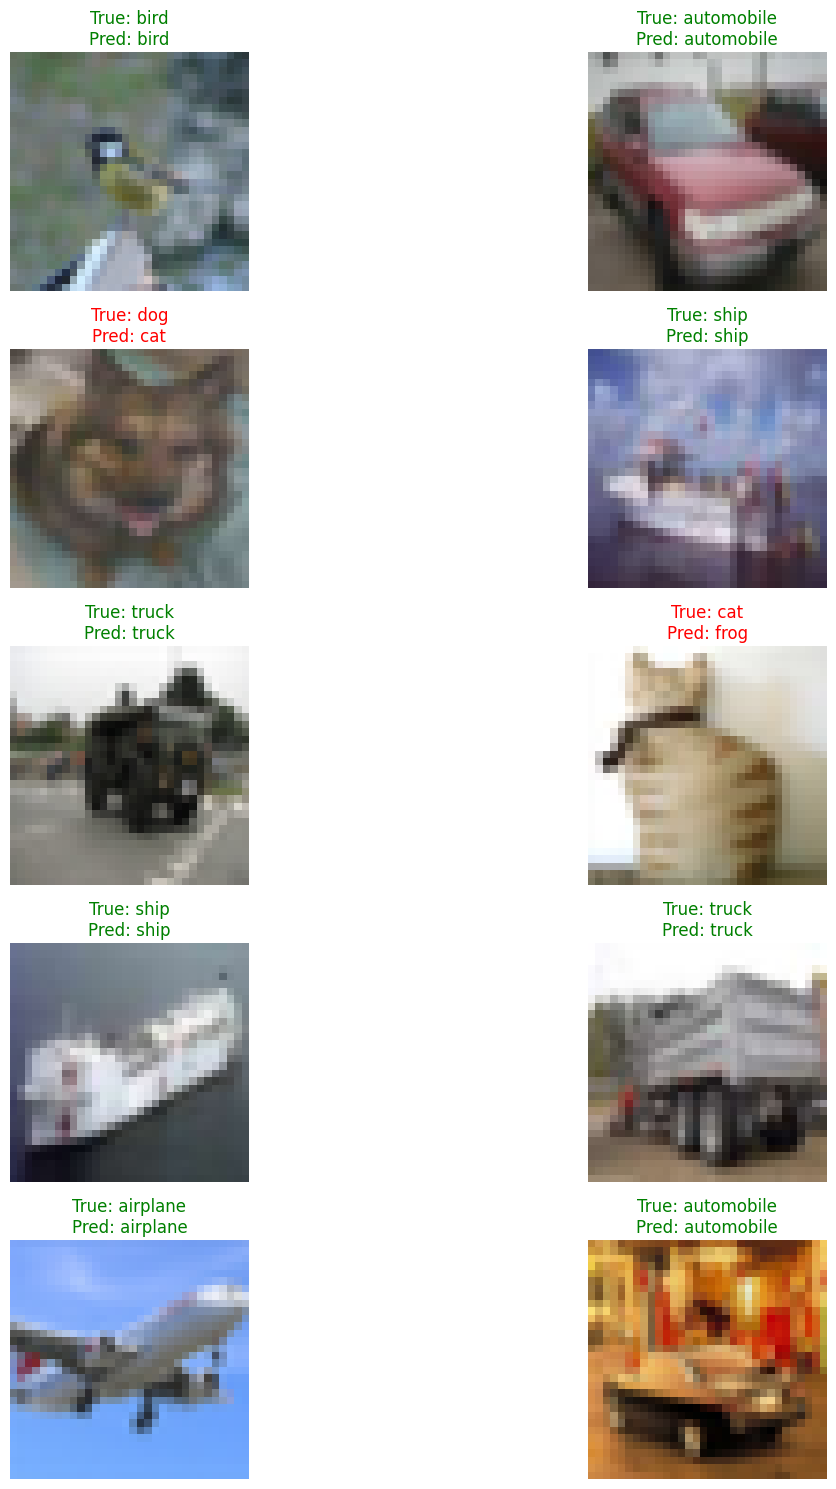

Displaying 10 predictions from the `cnn_combined` model.


In [ ]:
import matplotlib.pyplot as plt

# Select a few random images from the test set
num_predictions_to_show = 10
np.random.seed(42) # for reproducibility
random_indices = np.random.choice(len(xtest), num_predictions_to_show, replace=False)

sample_images = xtest[random_indices]
sample_true_labels = ytest[random_indices]

# Predict with the best model (cnn_combined)
predictions = cnn_combined.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)

# Visualize the predictions
plt.figure(figsize=(15, 15))
for i in range(num_predictions_to_show):
    plt.subplot(5, 2, i + 1)
    plt.imshow(sample_images[i])
    true_label_name = class_names[sample_true_labels[i][0]]
    predicted_label_name = class_names[predicted_classes[i]]

    color = "green" if true_label_name == predicted_label_name else "red"
    title = f"True: {true_label_name}\nPred: {predicted_label_name}"
    plt.title(title, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Displaying {num_predictions_to_show} predictions from the `cnn_combined` model.")

### Interactive Prediction with User Input

Now that we have saved our best model (`cnn_combined`), let's create an interactive widget that allows you to upload an image and get a prediction from the model. This will demonstrate how to use the model for inference on new, unseen data.

In [ ]:
cnn_combined.save('best_cnn_model_cifar10.keras')
print("Best model (cnn_combined) saved as 'best_cnn_model_cifar10.keras'")

Best model (cnn_combined) saved as 'best_cnn_model_cifar10.keras'


In [2]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 75.4 MB/s eta 0:00:00


In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io
import numpy as np
from tensorflow.keras.models import load_model

# Load the saved best model
loaded_model = load_model('best_cnn_model_cifar10.keras')
print("Best model loaded successfully.")

# Define the class names (as used during training)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

ValueError: File not found: filepath=best_cnn_model_cifar10.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
def predict_uploaded_image(change):
    with output_widget:
        clear_output()
        if not file_upload.value:
            print("Please upload an image.")
            return

        # Get the uploaded file content
        uploaded_file = list(file_upload.value.values())[0]
        content = uploaded_file['content']

        try:
            # Open the image using PIL
            image = Image.open(io.BytesIO(content))

            # Preprocess the image:
            # 1. Resize to (32, 32) as expected by the model
            # 2. Convert to numpy array
            image_resized = image.resize((32, 32))
            image_array = np.array(image_resized)

            # Ensure the image has 3 channels if it's grayscale or has an alpha channel
            if image_array.ndim == 2: # Grayscale
                image_array = np.stack((image_array,)*3, axis=-1)
            elif image_array.shape[-1] == 4: # RGBA
                image_array = image_array[..., :3] # Take only RGB channels

            # No normalization needed here, as the model was trained on 0-255 pixel values.
            image_for_prediction = np.expand_dims(image_array, axis=0)

            # Make prediction
            prediction = loaded_model.predict(image_for_prediction)
            predicted_class_index = np.argmax(prediction)
            predicted_class_name = class_names[predicted_class_index]
            confidence = prediction[0][predicted_class_index] * 100

            # Display the uploaded image and prediction
            plt.figure(figsize=(4, 4))
            plt.imshow(image_resized) # Display the resized image
            plt.title(f"Prediction: {predicted_class_name} ({confidence:.2f}% confidence)")
            plt.axis('off')
            plt.show()

        except Exception as e:
            print(f"Error processing image: {e}")

# Create a file upload widget
file_upload = widgets.FileUpload(accept='image/*', multiple=False)
output_widget = widgets.Output()

# Attach the prediction function to the upload widget's on_change event
file_upload.observe(predict_uploaded_image, names='value')

# Display the widgets
display(file_upload, output_widget)

FileUpload(value={}, accept='image/*', description='Upload')

Output()